In [5]:
#Task 1: Load and Understand the Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("C:\\Users\\nnish\\Downloads\\customer_support_escalation_dataset.csv")

print('Dataset Size')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print('\nColumn Names')
print(df.columns.tolist())
print('\nData Types')
print(df.dtypes)
print('\nMissing Values')
print(df.isnull().sum())
print('\nDuplicate Records')
print(df.duplicated().sum())
print('\nTarget Variable Distribution')
print(df['ticket_escalated'].value_counts())
print(df['ticket_escalated'].value_counts(normalize=True).round(3))

Dataset Size
Rows: 350, Columns: 17

Column Names
['ticket_id', 'customer_age', 'age_group', 'gender', 'region', 'customer_type', 'product_category', 'support_channel', 'priority_level', 'time_to_first_response_minutes', 'number_of_messages', 'issue_duration_hours', 'previous_tickets', 'agent_satisfaction_score', 'customer_satisfaction_score', 'refund_requested', 'ticket_escalated']

Data Types
ticket_id                          object
customer_age                        int64
age_group                          object
gender                             object
region                             object
customer_type                      object
product_category                   object
support_channel                    object
priority_level                     object
time_to_first_response_minutes    float64
number_of_messages                  int64
issue_duration_hours              float64
previous_tickets                    int64
agent_satisfaction_score            int64
customer_satis

In [6]:
#Task 2: Define Features and Target Variable

target_col    = 'ticket_escalated'
drop_cols     = ['ticket_id']
fairness_cols = ['age_group', 'gender', 'region', 'customer_type']
feature_cols  = [c for c in df.columns if c not in drop_cols + [target_col] + fairness_cols]

print('Target Variable  :', target_col)
print('Input Features   :', feature_cols)
print('Removed (ID)     :', drop_cols)
print('Fairness Only    :', fairness_cols)

Target Variable  : ticket_escalated
Input Features   : ['customer_age', 'product_category', 'support_channel', 'priority_level', 'time_to_first_response_minutes', 'number_of_messages', 'issue_duration_hours', 'previous_tickets', 'agent_satisfaction_score', 'customer_satisfaction_score', 'refund_requested']
Removed (ID)     : ['ticket_id']
Fairness Only    : ['age_group', 'gender', 'region', 'customer_type']


In [9]:
#Task 3: Data Preprocessing

from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

median_val = df_model['time_to_first_response_minutes'].median()
df_model['time_to_first_response_minutes'] = df_model['time_to_first_response_minutes'].fillna(median_val)
print(f'Filled missing values with median: {median_val}')

cat_cols = df_model[feature_cols].select_dtypes(include=['object']).columns.tolist()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le
    print(f'Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X = df_model[feature_cols]
y = df_model[target_col]
print(f'\nFinal feature matrix shape: {X.shape}')
print(X.head(3))

Filled missing values with median: 242.0
Encoded product_category: {'Account': np.int64(0), 'Billing': np.int64(1), 'Delivery': np.int64(2), 'Hardware': np.int64(3), 'Software': np.int64(4)}
Encoded support_channel: {'Chat': np.int64(0), 'Email': np.int64(1), 'Phone': np.int64(2), 'Web Form': np.int64(3)}
Encoded priority_level: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Encoded refund_requested: {'No': np.int64(0), 'Yes': np.int64(1)}

Final feature matrix shape: (350, 11)
   customer_age  product_category  support_channel  priority_level  \
0            38                 3                0               0   
1            52                 2                3               1   
2            63                 0                2               1   

   time_to_first_response_minutes  number_of_messages  issue_duration_hours  \
0                            72.0                  13                  61.7   
1                            77.0                  19       

In [11]:
#Task 4: Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set : {X_train.shape[0]} records (80%)')
print(f'Testing set  : {X_test.shape[0]} records (20%)')
print('\nTraining target distribution')
print(y_train.value_counts())
print('\nTesting target distribution')
print(y_test.value_counts())

Training set : 280 records (80%)
Testing set  : 70 records (20%)

Training target distribution
ticket_escalated
1    270
0     10
Name: count, dtype: int64

Testing target distribution
ticket_escalated
1    63
0     7
Name: count, dtype: int64


In [13]:
#Task 5: Train a Classification Model

from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

comparison = pd.DataFrame({
    'Actual'   : y_test.values,
    'Predicted': y_pred,
    'Correct'  : y_test.values == y_pred
}).reset_index(drop=True)

print('First 10 predictions')
print(comparison.head(10).to_string(index=False))
print(f'\nTotal Correct : {comparison["Correct"].sum()}')
print(f'Total Wrong   : {(~comparison["Correct"]).sum()}')

First 10 predictions
 Actual  Predicted  Correct
      1          1     True
      1          1     True
      0          1    False
      1          1     True
      1          1     True
      1          1     True
      1          1     True
      1          1     True
      1          1     True
      1          1     True

Total Correct : 63
Total Wrong   : 7


In [14]:
#Task 6: Evaluate the Model

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score' : [round(accuracy,4), round(precision,4), round(recall,4), round(f1,4)]
})
print('Evaluation Metrics')
print(metrics_df.to_string(index=False))
print('\nFull Classification Report')
print(classification_report(y_test, y_pred, zero_division=0))

Evaluation Metrics
   Metric  Score
 Accuracy 0.9000
Precision 0.9118
   Recall 0.9841
 F1-Score 0.9466

Full Classification Report
              precision    recall  f1-score   support

           0       0.50      0.14      0.22         7
           1       0.91      0.98      0.95        63

    accuracy                           0.90        70
   macro avg       0.71      0.56      0.58        70
weighted avg       0.87      0.90      0.87        70



Confusion Matrix
                       Pred: Not Escalated  Pred: Escalated
Actual: Not Escalated                    1                6
Actual: Escalated                        1               62

True Negatives  (TN): 1
False Positives (FP): 6
False Negatives (FN): 1
True Positives  (TP): 62


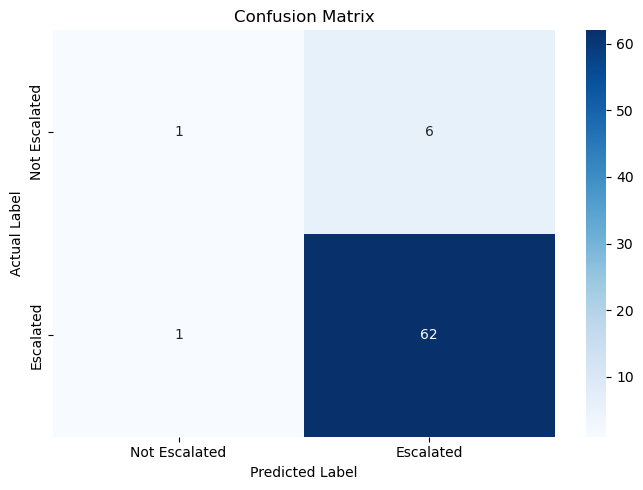

In [16]:
#Task 7: Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

cm_df = pd.DataFrame(cm,
    index   = ['Actual: Not Escalated', 'Actual: Escalated'],
    columns = ['Pred: Not Escalated',   'Pred: Escalated']
)
print('Confusion Matrix')
print(cm_df)
print(f'\nTrue Negatives  (TN): {tn}')
print(f'False Positives (FP): {fp}')
print(f'False Negatives (FN): {fn}')
print(f'True Positives  (TP): {tp}')

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Escalated', 'Escalated'],
            yticklabels=['Not Escalated', 'Escalated'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

Error Type Counts
Error Type
Correct           63
False Positive     6
False Negative     1
Name: count, dtype: int64

Wrong Predictions
    Actual  Predicted     Status      Error Type
2        0          1  Incorrect  False Positive
24       0          1  Incorrect  False Positive
29       0          1  Incorrect  False Positive
30       1          0  Incorrect  False Negative
32       0          1  Incorrect  False Positive
52       0          1  Incorrect  False Positive
63       0          1  Incorrect  False Positive


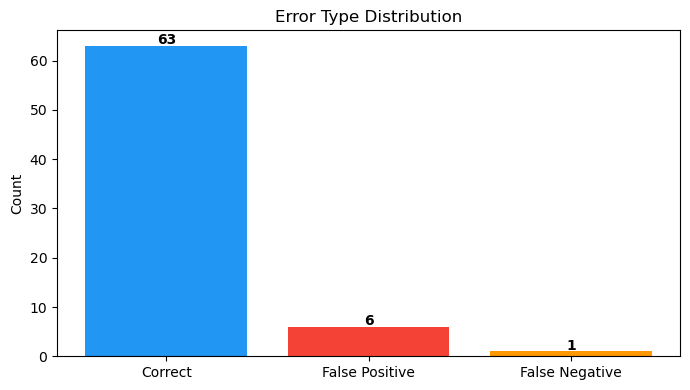

In [17]:
#Task 8: Error Analysis

def classify_error(row):
    if row['Actual'] == row['Predicted']:
        return 'Correct'
    elif row['Actual'] == 0 and row['Predicted'] == 1:
        return 'False Positive'
    else:
        return 'False Negative'

error_df = pd.DataFrame({
    'Actual'   : y_test.values,
    'Predicted': y_pred
}).reset_index(drop=True)

error_df['Status']     = np.where(
    error_df['Actual'].eq(error_df['Predicted']), 'Correct', 'Incorrect')
error_df['Error Type'] = error_df.apply(classify_error, axis=1)

print('Error Type Counts')
print(error_df['Error Type'].value_counts())
print('\nWrong Predictions')
print(error_df[error_df['Status'].eq('Incorrect')].to_string(index=True))

plt.figure(figsize=(7, 4))
error_counts = error_df['Error Type'].value_counts()
bars = plt.bar(error_counts.index, error_counts.values,
               color=['#2196F3', '#F44336', '#FF9800'])
for bar, val in zip(bars, error_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', fontweight='bold')
plt.title('Error Type Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150)
plt.show()

Cross-Validation Results
  Fold 1: 0.9286
  Fold 2: 0.9286
  Fold 3: 0.8857
  Fold 4: 0.9571
  Fold 5: 0.9286

Mean CV Accuracy : 0.9257
Std Dev          : 0.0229


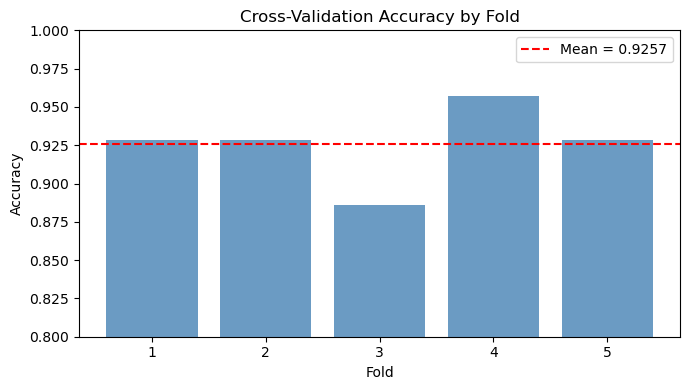

In [18]:
#Task 9: Cross-Validation

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')

print('Cross-Validation Results')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\nMean CV Accuracy : {cv_scores.mean():.4f}')
print(f'Std Dev          : {cv_scores.std():.4f}')

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.8)
plt.axhline(cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean = {cv_scores.mean():.4f}')
plt.title('Cross-Validation Accuracy by Fold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.ylim([0.8, 1.0])
plt.legend()
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150)
plt.show()

Overfitting Analysis
Training Accuracy : 1.0000
Testing Accuracy  : 0.9000
Gap               : 0.1000
 Depth  Train   Test    Gap
     1 0.9643 0.9000 0.0643
     2 0.9643 0.9000 0.0643
     3 0.9750 0.9000 0.0750
     4 0.9786 0.9000 0.0786
     5 0.9857 0.9143 0.0714
     6 0.9929 0.9000 0.0929
     7 0.9964 0.9000 0.0964
     8 1.0000 0.9000 0.1000
     9 1.0000 0.9000 0.1000
    10 1.0000 0.9000 0.1000
    11 1.0000 0.9000 0.1000
    12 1.0000 0.9000 0.1000
    13 1.0000 0.9000 0.1000
    14 1.0000 0.9000 0.1000
    15 1.0000 0.9000 0.1000


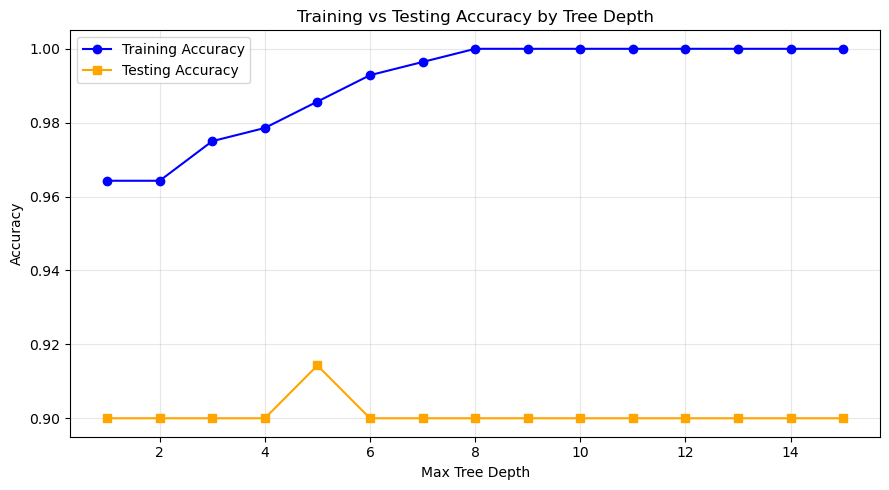

In [19]:
#Task 10: Overfitting and Underfitting Analysis

train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print('Overfitting Analysis')
print(f'Training Accuracy : {train_acc:.4f}')
print(f'Testing Accuracy  : {test_acc:.4f}')
print(f'Gap               : {train_acc - test_acc:.4f}')

depths       = list(range(1, 16))
train_scores = []
test_scores  = []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, m.predict(X_train)))
    test_scores.append(accuracy_score(y_test, m.predict(X_test)))

depth_df = pd.DataFrame({
    'Depth': depths,
    'Train': [round(s,4) for s in train_scores],
    'Test' : [round(s,4) for s in test_scores]
})
depth_df['Gap'] = (depth_df['Train'] - depth_df['Test']).round(4)
print(depth_df.to_string(index=False))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, 'o-', label='Training Accuracy', color='blue')
plt.plot(depths, test_scores,  's-', label='Testing Accuracy',  color='orange')
plt.title('Training vs Testing Accuracy by Tree Depth')
plt.xlabel('Max Tree Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('overfitting_analysis.png', dpi=150)
plt.show()

Feature Importance
                       Feature  Importance
time_to_first_response_minutes      0.5029
            number_of_messages      0.1725
   customer_satisfaction_score      0.1171
              previous_tickets      0.0951
      agent_satisfaction_score      0.0691
          issue_duration_hours      0.0432
                  customer_age      0.0000
              product_category      0.0000
               support_channel      0.0000
                priority_level      0.0000
              refund_requested      0.0000


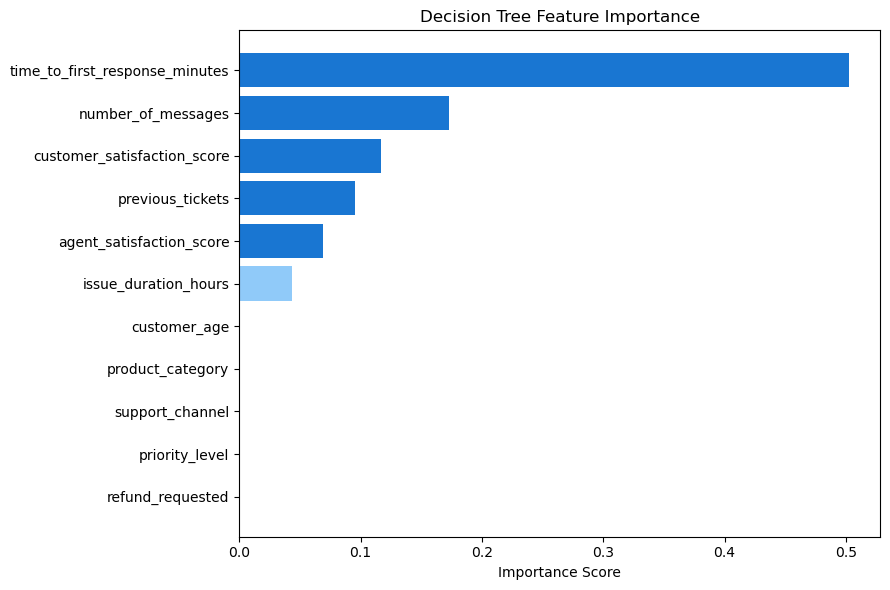

In [21]:
#Task 11: Feature Importance

feature_importance = pd.Series(
    clf.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

fi_df = feature_importance.reset_index()
fi_df.columns = ['Feature', 'Importance']
fi_df['Importance'] = fi_df['Importance'].round(4)

print('Feature Importance')
print(fi_df.to_string(index=False))

plt.figure(figsize=(9, 6))
colors = ['#1976D2' if i < 5 else '#90CAF9' for i in range(len(feature_importance))]
plt.barh(feature_importance.index[::-1], feature_importance.values[::-1], color=colors[::-1])
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

SHAP Summary
  customer_satisfaction_score              0.0220
  previous_tickets                         0.0142
  time_to_first_response_minutes           0.0052
  number_of_messages                       0.0046
  issue_duration_hours                     0.0040
  customer_age                             0.0000
  product_category                         0.0000
  support_channel                          0.0000
  priority_level                           0.0000
  agent_satisfaction_score                 0.0000
  refund_requested                         0.0000

SHAP for Record 0
  Actual: 1, Predicted: 1
customer_age                      0.0000
product_category                  0.0000
support_channel                   0.0000
priority_level                    0.0000
time_to_first_response_minutes    0.0000
number_of_messages                0.0000
issue_duration_hours              0.0000
previous_tickets                  0.0000
agent_satisfaction_score          0.0000
refund_requested       

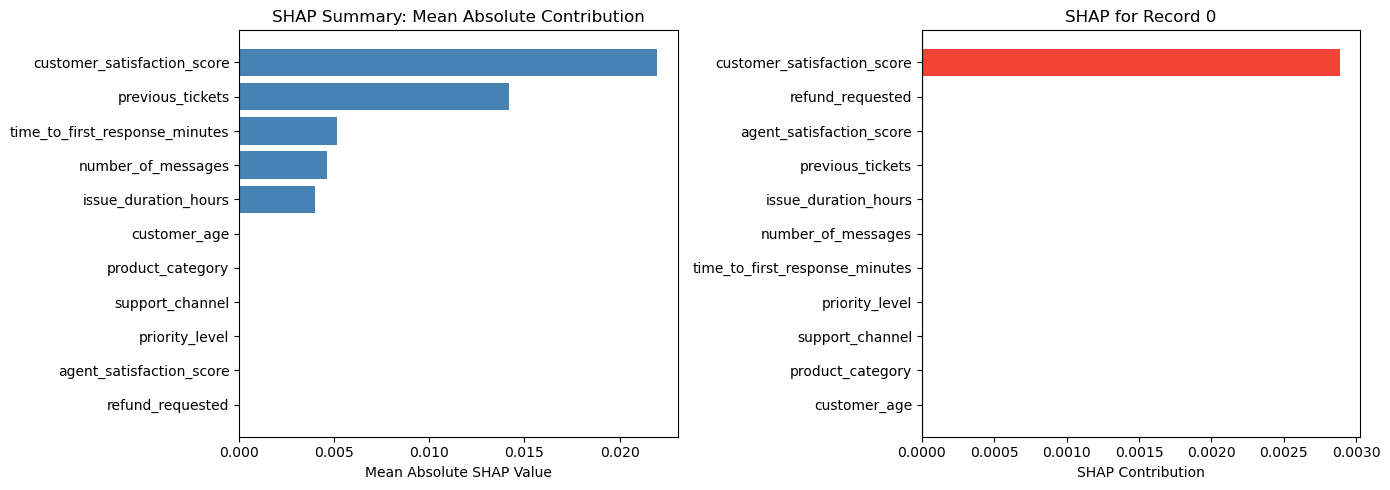

In [23]:
#Task 12: SHAP Explanation

from sklearn.tree import _tree

def tree_shap_approx(model, X_data, feature_names):
    tree_          = model.tree_
    contribs       = np.zeros((len(X_data), X_data.shape[1]))
    node_indicator = model.decision_path(X_data)

    for sample_idx in range(len(X_data)):
        node_ids = node_indicator[sample_idx].indices
        for node_id in node_ids:
            if tree_.children_left[node_id] == _tree.TREE_LEAF:
                continue
            feat    = tree_.feature[node_id]
            left    = tree_.children_left[node_id]
            right   = tree_.children_right[node_id]
            p_node  = tree_.value[node_id][0][1] / tree_.n_node_samples[node_id]
            if X_data.iloc[sample_idx, feat] <= tree_.threshold[node_id]:
                p_child = tree_.value[left][0][1]  / tree_.n_node_samples[left]
            else:
                p_child = tree_.value[right][0][1] / tree_.n_node_samples[right]
            contribs[sample_idx, feat] += (p_child - p_node)
    return contribs

shap_vals = tree_shap_approx(clf, X_test.reset_index(drop=True), feature_cols)

shap_summary = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)

print('SHAP Summary')
for feat, val in shap_summary.items():
    print(f'  {feat:<40} {val:.4f}')

record_idx      = 0
individual_shap = pd.Series(shap_vals[record_idx], index=feature_cols).sort_values()
print(f'\nSHAP for Record {record_idx}')
print(f'  Actual: {y_test.values[record_idx]}, Predicted: {y_pred[record_idx]}')
print(individual_shap.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(shap_summary.index[::-1], shap_summary.values[::-1], color='steelblue')
axes[0].set_title('SHAP Summary: Mean Absolute Contribution')
axes[0].set_xlabel('Mean Absolute SHAP Value')

colors_ind = ['#F44336' if v > 0 else '#2196F3' for v in individual_shap.values]
axes[1].barh(individual_shap.index, individual_shap.values, color=colors_ind)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title(f'SHAP for Record {record_idx}')
axes[1].set_xlabel('SHAP Contribution')

plt.tight_layout()
plt.savefig('shap_explanation.png', dpi=150)
plt.show()

In [24]:
#Task 13: LIME Explanation